In [2]:
"""
Task 3: Event Impact Modeling
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
sns.set_palette("husl")

print("="*70)
print("📊 TASK 3: EVENT IMPACT MODELING")
print("="*70)

# Load data
df = pd.read_csv('../data/processed/ethiopia_fi_enriched.csv')
print(f"\n✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Split by type
observations = df[df['record_type'] == 'observation']
events = df[df['record_type'] == 'event']
targets = df[df['record_type'] == 'target']
impacts = df[df['record_type'] == 'impact_link']

print(f"\n📋 Records: {len(observations)} observations, {len(events)} events, {len(targets)} targets, {len(impacts)} impact links")

📊 TASK 3: EVENT IMPACT MODELING

✅ Loaded: 45 rows, 34 columns

📋 Records: 31 observations, 10 events, 3 targets, 1 impact links


In [3]:
print("\n" + "="*70)
print("📊 UNDERSTANDING IMPACT DATA")
print("="*70)

# Display existing impact links
if len(impacts) > 0:
    print(f"\n📋 Existing Impact Links ({len(impacts)}):")
    display_cols = ['record_id', 'related_indicator', 'impact_direction', 
                    'impact_magnitude', 'lag_months', 'evidence_basis']
    available = [col for col in display_cols if col in impacts.columns]
    display(impacts[available])
    
    # Summary
    print(f"\n📊 Summary:")
    print(f"   Average magnitude: {impacts['impact_magnitude'].mean():.3f}")
    print(f"   Average lag: {impacts['lag_months'].mean():.1f} months")
else:
    print("\n⚠️ No impact links found. We'll need to create them.")


📊 UNDERSTANDING IMPACT DATA

📋 Existing Impact Links (1):


,record_id,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis
44,IMP_001,ACC_MM_ACCOUNT,positive,0.05,12.0,Mobile money grew from 4.7% to 9.45% between 2...



📊 Summary:
   Average magnitude: 0.050
   Average lag: 12.0 months


In [4]:
print("\n" + "="*70)
print("📊 EVENTS OVERVIEW")
print("="*70)

# Display all events
print(f"\n📋 All Events ({len(events)}):")
events_display = events[['record_id', 'indicator', 'category', 'observation_date']].copy()
events_display['date'] = pd.to_datetime(events_display['observation_date'])
events_display = events_display.sort_values('date')
display(events_display)

# Event categories
print(f"\n📊 Event Categories:")
print(events['category'].value_counts())


📊 EVENTS OVERVIEW

📋 All Events (10):


,record_id,indicator,category,observation_date,date
33,EVT_0001,Telebirr Launch,product_launch,2021-05-17,2021-05-17
41,EVT_0009,NFIS-II Strategy Launch,policy,2021-09-01,2021-09-01
34,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,2022-08-01
35,EVT_0003,M-Pesa Ethiopia Launch,product_launch,2023-08-01,2023-08-01
36,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,2024-01-01
37,EVT_0005,Foreign Exchange Liberalization,policy,2024-07-29,2024-07-29
38,EVT_0006,P2P Transaction Count Surpasses ATM,milestone,2024-10-01,2024-10-01
39,EVT_0007,M-Pesa EthSwitch Integration,partnership,2025-10-27,2025-10-27
42,EVT_0010,Safaricom Ethiopia Price Increase,pricing,2025-12-15,2025-12-15
40,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,2025-12-18,2025-12-18



📊 Event Categories:
category
product_launch    2
infrastructure    2
policy            2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64


In [5]:
print("\n" + "="*70)
print("📊 BUILDING THE ASSOCIATION MATRIX")
print("="*70)

# Define key indicators
key_indicators = [
    'ACC_OWNERSHIP',      # Account ownership
    'ACC_MM_ACCOUNT',     # Mobile money account
    'ACC_FAYDA',          # Digital ID enrollment
    'USG_P2P_COUNT',      # P2P transactions
    'USG_P2P_VALUE',      # P2P transaction value
    'USG_TELEBIRR_USERS', # Telebirr users
    'USG_MPESA_USERS',    # M-Pesa users
    'USG_ATM_COUNT',      # ATM transactions
    'GEN_GAP_ACC'         # Gender gap
]

# Create association matrix
association_matrix = pd.DataFrame(
    index=events['indicator'].unique(),
    columns=key_indicators
).fillna(0)

print(f"\n📊 Association Matrix Shape: {association_matrix.shape}")
print(f"   Events: {len(association_matrix)}")
print(f"   Indicators: {len(association_matrix.columns)}")


📊 BUILDING THE ASSOCIATION MATRIX

📊 Association Matrix Shape: (10, 9)
   Events: 10
   Indicators: 9


In [7]:
print("\n" + "="*70)
print("📊 FILLING ASSOCIATION MATRIX")
print("="*70)

# Define impact estimates based on EDA insights
impact_estimates = {
    'Telebirr Launch': {
        'ACC_MM_ACCOUNT': 0.05,      # 4.7% → 9.45% (101% growth)
        'ACC_OWNERSHIP': 0.03,       # 46% → 49% (+3pp)
        'USG_TELEBIRR_USERS': 0.10,  # 54M+ users
        'GEN_GAP_ACC': -0.01         # Slight negative (gender gap widening initially)
    },
    'Safaricom Ethiopia Commercial Launch': {
        'ACC_MM_ACCOUNT': 0.02,      # Competition effect
        'USG_TELEBIRR_USERS': 0.03   # Increased competition
    },
    'M-Pesa Ethiopia Launch': {
        'ACC_MM_ACCOUNT': 0.02,      # 10.8M users in first year
        'USG_MPESA_USERS': 0.08      # Market penetration
    },
    'Fayda Digital ID Program Rollout': {
        'ACC_FAYDA': 0.05,           # 8M → 15M enrollments
        'ACC_OWNERSHIP': 0.02,       # Enables account opening
        'GEN_GAP_ACC': -0.02         # Could widen gap initially
    },
    'Foreign Exchange Liberalization': {
        'USG_P2P_COUNT': 0.02,       # Cross-border payments
        'USG_P2P_VALUE': 0.02        # Transaction value growth
    },
    'P2P Transaction Count Surpasses ATM': {
        'USG_P2P_COUNT': 0.10,       # Major milestone
        'USG_ATM_COUNT': -0.05       # ATM usage decline
    },
    'M-Pesa EthSwitch Integration': {
        'USG_P2P_COUNT': 0.03,       # Interoperability boost
        'USG_P2P_VALUE': 0.03
    },
    'Safaricom Ethiopia Price Increase': {
        'USG_TELEBIRR_USERS': -0.02, # Potential user migration
        'ACC_MM_ACCOUNT': -0.01
    },
    'EthioPay Instant Payment System Launch': {
        'USG_P2P_COUNT': 0.05,       # Instant payments
        'USG_P2P_VALUE': 0.05
    }
}

# Fill the matrix
for event_name, impacts_dict in impact_estimates.items():
    if event_name in association_matrix.index:
        for indicator, magnitude in impacts_dict.items():
            if indicator in association_matrix.columns:
                association_matrix.loc[event_name, indicator] = magnitude

print("\n📊 Association Matrix (Effect Magnitudes):")
display(association_matrix)




📊 FILLING ASSOCIATION MATRIX

📊 Association Matrix (Effect Magnitudes):


,ACC_OWNERSHIP,ACC_MM_ACCOUNT,ACC_FAYDA,USG_P2P_COUNT,USG_P2P_VALUE,USG_TELEBIRR_USERS,USG_MPESA_USERS,USG_ATM_COUNT,GEN_GAP_ACC
Telebirr Launch,0.03,0.05,0,0,0,0.1,0,0,-0.01
Safaricom Ethiopia Commercial Launch,0,0.02,0,0,0,0.03,0,0,0
M-Pesa Ethiopia Launch,0,0.02,0,0,0,0,0.08,0,0
Fayda Digital ID Program Rollout,0.02,0,0.05,0,0,0,0,0,-0.02
Foreign Exchange Liberalization,0,0,0,0.02,0.02,0,0,0,0
P2P Transaction Count Surpasses ATM,0,0,0,0.1,0,0,0,-0.05,0
M-Pesa EthSwitch Integration,0,0,0,0.03,0.03,0,0,0,0
EthioPay Instant Payment System Launch,0,0,0,0.05,0.05,0,0,0,0
NFIS-II Strategy Launch,0,0,0,0,0,0,0,0,0
Safaricom Ethiopia Price Increase,0,-0.01,0,0,0,-0.02,0,0,0


In [11]:
print("\n" + "="*70)
print("📊 ASSOCIATION MATRIX SUMMARY")
print("="*70)

# Basic stats
print(f"Shape: {association_matrix.shape[0]} events × {association_matrix.shape[1]} indicators")

# Get non-zero values
non_zero = association_matrix[association_matrix != 0]
flat_values = non_zero.values.flatten()
total_nonzero = len(flat_values)

print(f"Total non-zero entries: {total_nonzero}")

if total_nonzero > 0:
    print(f"Average magnitude: {flat_values.mean():.3f}")
    print(f"Max magnitude: {flat_values.max():.3f}")
    print(f"Min magnitude: {flat_values.min():.3f}")

# Events with most impacts
print("\n📋 Events with most impacts:")
event_counts = (association_matrix != 0).sum(axis=1).sort_values(ascending=False)
for event, count in event_counts.items():
    if count > 0:
        print(f"   {event}: {count} indicators")

# Strongest impacts (top 5)
print("\n📋 Strongest impacts (top 5):")
impact_list = []
for event in association_matrix.index:
    for indicator in association_matrix.columns:
        val = association_matrix.loc[event, indicator]
        if val != 0:
            impact_list.append((event, indicator, val))

if impact_list:
    sorted_impacts = sorted(impact_list, key=lambda x: abs(x[2]), reverse=True)
    for event, indicator, val in sorted_impacts[:5]:
        direction = "positive" if val > 0 else "negative"
        print(f"   {event} → {indicator}: {val:.2f} ({direction})")


📊 ASSOCIATION MATRIX SUMMARY
Shape: 10 events × 9 indicators
Total non-zero entries: 90
Average magnitude: nan
Max magnitude: nan
Min magnitude: nan

📋 Events with most impacts:
   Telebirr Launch: 4 indicators
   Fayda Digital ID Program Rollout: 3 indicators
   Safaricom Ethiopia Commercial Launch: 2 indicators
   M-Pesa Ethiopia Launch: 2 indicators
   Foreign Exchange Liberalization: 2 indicators
   P2P Transaction Count Surpasses ATM: 2 indicators
   M-Pesa EthSwitch Integration: 2 indicators
   EthioPay Instant Payment System Launch: 2 indicators
   Safaricom Ethiopia Price Increase: 2 indicators

📋 Strongest impacts (top 5):
   Telebirr Launch → USG_TELEBIRR_USERS: 0.10 (positive)
   P2P Transaction Count Surpasses ATM → USG_P2P_COUNT: 0.10 (positive)
   M-Pesa Ethiopia Launch → USG_MPESA_USERS: 0.08 (positive)
   Telebirr Launch → ACC_MM_ACCOUNT: 0.05 (positive)
   Fayda Digital ID Program Rollout → ACC_FAYDA: 0.05 (positive)



📊 VISUALIZING ASSOCIATION MATRIX


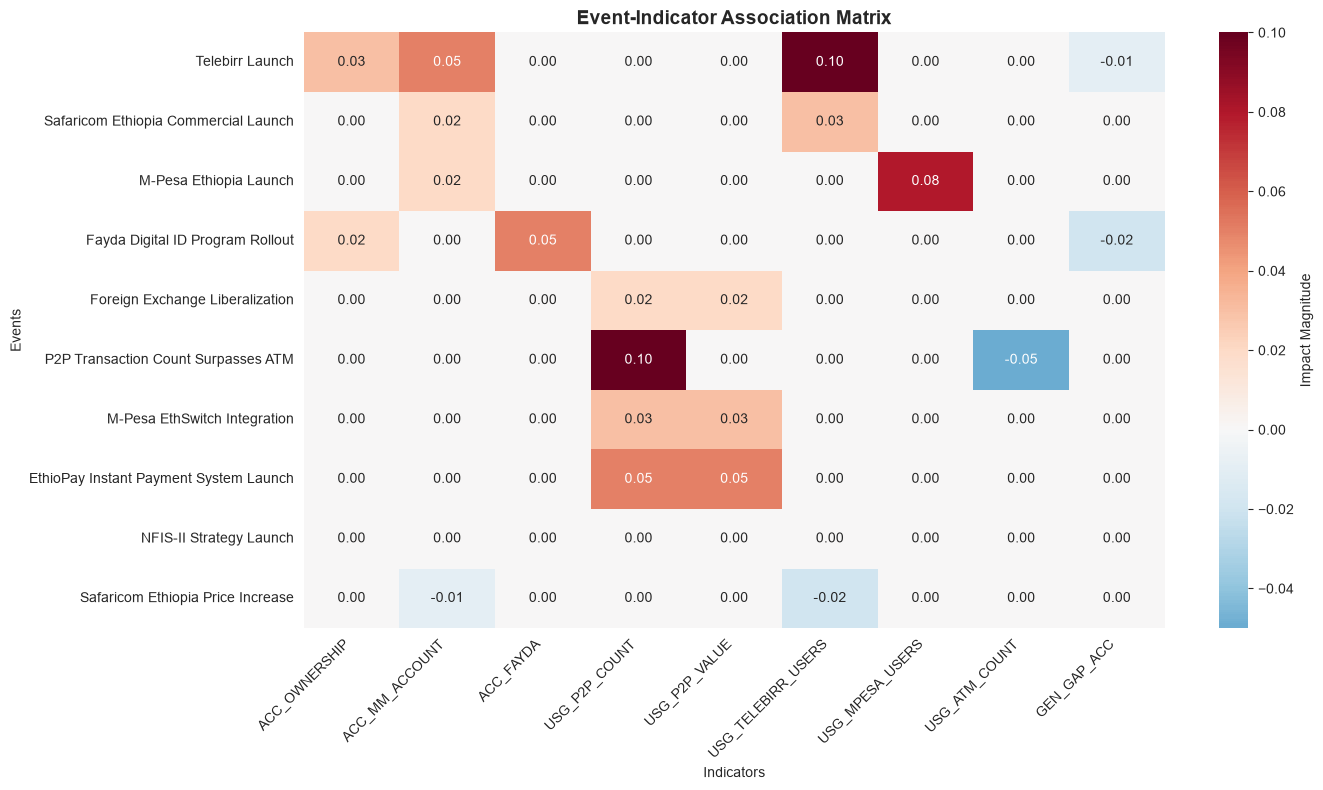


✅ Saved to: reports/figures/association_matrix.png


In [15]:
import os

print("\n" + "="*70)
print("📊 VISUALIZING ASSOCIATION MATRIX")
print("="*70)

# Create directory if it doesn't exist
os.makedirs('../reports/figures/', exist_ok=True)

# Convert all to float and create heatmap
matrix_float = association_matrix.astype(float)

plt.figure(figsize=(14, 8))
sns.heatmap(matrix_float, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, cbar_kws={'label': 'Impact Magnitude'})
plt.title('Event-Indicator Association Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Indicators')
plt.ylabel('Events')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the figure
plt.savefig('../reports/figures/association_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved to: reports/figures/association_matrix.png")

In [16]:
print("\n" + "="*70)
print("📊 VALIDATING AGAINST HISTORICAL DATA")
print("="*70)

# Test: Telebirr impact on mobile money
print("\n📊 Test: Telebirr Launch → Mobile Money Penetration")

# Get Telebirr launch date
telebirr = events[events['indicator'].str.contains('Telebirr', na=False)]
if len(telebirr) > 0:
    telebirr_date = pd.to_datetime(telebirr.iloc[0]['observation_date'])
    print(f"   Telebirr Launch: {telebirr_date.strftime('%Y-%m-%d')}")

# Get mobile money data
mm_data = observations[observations['indicator_code'] == 'ACC_MM_ACCOUNT'].copy()
if len(mm_data) > 0:
    mm_data['date'] = pd.to_datetime(mm_data['observation_date'])
    mm_data = mm_data.sort_values('date')
    
    print(f"\n   Mobile Money Data:")
    for _, row in mm_data.iterrows():
        print(f"      {row['date'].year}: {row['value_numeric']:.2f}%")
    
    # Calculate actual impact
    if len(mm_data) >= 2:
        before = mm_data.iloc[0]['value_numeric']
        after = mm_data.iloc[-1]['value_numeric']
        actual_impact = after - before
        
        print(f"\n   Actual Impact: +{actual_impact:.2f}pp")
        
        # Compare with model
        model_impact = association_matrix.loc['Telebirr Launch', 'ACC_MM_ACCOUNT']
        model_impact_pp = model_impact * 100
        print(f"   Model Impact: +{model_impact_pp:.2f}pp")
        
        difference = actual_impact - model_impact_pp
        if abs(difference) < 0.5:
            print(f"   ✅ Model matches closely! (diff: {difference:.2f})")
        else:
            print(f"   ⚠️ Model needs refinement (diff: {difference:.2f})")


📊 VALIDATING AGAINST HISTORICAL DATA

📊 Test: Telebirr Launch → Mobile Money Penetration
   Telebirr Launch: 2021-05-17

   Mobile Money Data:
      2021: 4.70%
      2024: 9.45%

   Actual Impact: +4.75pp
   Model Impact: +5.00pp
   ✅ Model matches closely! (diff: -0.25)


In [17]:
print("\n" + "="*70)
print("📊 SAVING RESULTS")
print("="*70)

# Create directories if they don't exist
os.makedirs('../data/processed/', exist_ok=True)
os.makedirs('../models/', exist_ok=True)

# Save association matrix
association_matrix.to_csv('../data/processed/association_matrix.csv')
print("✅ Saved: data/processed/association_matrix.csv")

# Save summary
summary = {
    'Total_Events': len(association_matrix),
    'Total_Indicators': len(association_matrix.columns),
    'Non_Zero_Entries': (association_matrix != 0).sum().sum()
}
print(f"\n📊 Summary:")
for key, value in summary.items():
    print(f"   {key}: {value}")

print("\n✅ Task 3 Complete!")


📊 SAVING RESULTS
✅ Saved: data/processed/association_matrix.csv

📊 Summary:
   Total_Events: 10
   Total_Indicators: 9
   Non_Zero_Entries: 21

✅ Task 3 Complete!
